In [2]:
from spisea import synthetic, atmospheres, reddening, evolution
from astropy.io import fits
import matplotlib.pyplot as plt
import pysynphot
import numpy as np
from scipy.optimize import curve_fit
import os.path
import copy
import pandas as pd
import pysynphot as psp

/Users/mhuston/anaconda3/lib/python3.11/site-packages/pysynphot/locations.py:345: UserWarning: Extinction files not found in /Users/mhuston/NotBacked/spisea_data/cdbs/extinction
  warnings.warn('Extinction files not found in %s' % (extdir, ))


In [1]:
%load_ext autoreload
%autoreload 2

In [70]:
# Grids v1 and v2 are latest roman filters w/ different Teff grids, Vega mags
# Grids v3 use AB mag (converted the SPISEA spec mags) 

# Set up grid + fitting functions

In [3]:
evo_model = evolution.MISTv1(version=1.2,synthpop_extension=True) 
atm_func = atmospheres.get_merged_atmosphere
red_law = reddening.RedLawSODC(Rv=2.5)
wd_atm_func = atmospheres.get_wd_atmosphere

In [4]:
def get_filt(flt):
    flt_name = 'roman,wfi,'+flt
    filt = synthetic.get_filter_info(flt_name)
    return filt

def get_eff_lam(flt):
    flt_name = 'roman,wfi,'+flt
    filt = synthetic.get_filter_info(flt_name)
    obs = pysynphot.Observation(pysynphot.Vega, filt).efflam()
    assert str(filt.waveunits) == 'angstrom'
    return obs

def get_piv_lam(flt):
    flt_name = 'roman,wfi,'+flt
    filt = synthetic.get_filter_info(flt_name)
    obs = filt.pivot()
    assert str(filt.waveunits) == 'angstrom'
    return obs

def get_avg_lam(flt):
    flt_name = 'roman,wfi,'+flt
    filt = synthetic.get_filter_info(flt_name)
    obs = filt.avgwave()
    assert str(filt.waveunits) == 'angstrom'
    return obs

In [5]:
fname = os.path.join(os.environ['PYSYN_CDBS'], 'comp', 'nonhst', 'wfirst_wfi_f146_001_syn.fits')
bp = psp.FileBandpass(fname)

In [6]:
filts = ['f062','f087','f106','f129','f158','f184','f213','f146']
filt_avgs = [get_avg_lam(flt) for flt in filts]
Afiltavg_AKs = red_law.SODC(np.array(filt_avgs)*1e-4,1)
Afilteff_AKs = red_law.SODC(np.array([get_eff_lam(flt) for flt in filts])*1e-4,1)
Afiltpiv_AKs = red_law.SODC(np.array([get_piv_lam(flt) for flt in filts])*1e-4,1)

(/Users/mhuston/NotBacked/spisea_data/cdbs/comp/nonhst/roman_wfi_f062_003_syn.fits) does not have a defined binset in the wavecat table. The waveset of the spectrum will be used instead.
(/Users/mhuston/NotBacked/spisea_data/cdbs/comp/nonhst/roman_wfi_f087_003_syn.fits) does not have a defined binset in the wavecat table. The waveset of the spectrum will be used instead.
(/Users/mhuston/NotBacked/spisea_data/cdbs/comp/nonhst/roman_wfi_f106_003_syn.fits) does not have a defined binset in the wavecat table. The waveset of the spectrum will be used instead.
(/Users/mhuston/NotBacked/spisea_data/cdbs/comp/nonhst/roman_wfi_f129_003_syn.fits) does not have a defined binset in the wavecat table. The waveset of the spectrum will be used instead.
(/Users/mhuston/NotBacked/spisea_data/cdbs/comp/nonhst/roman_wfi_f158_003_syn.fits) does not have a defined binset in the wavecat table. The waveset of the spectrum will be used instead.
(/Users/mhuston/NotBacked/spisea_data/cdbs/comp/nonhst/roman_wfi_

In [68]:
filters_long=['roman,wfi,f062','roman,wfi,f087','roman,wfi,f106','roman,wfi,f129',
             'roman,wfi,f158','roman,wfi,f184','roman,wfi,f213','roman,wfi,f146']
mag_ab_vega = [synthetic.calc_ab_vega_filter_conversion(filt) for filt in filters_long]

def get_grid_phot(A_Ks, metallicity=0.0, rerun=False,logg=4.5):
    # Check for saved file
    filename = f'isos/grid_AKs_{A_Ks:1.2f}_met_{metallicity:1.2f}_logg_{logg:1.1f}.csv'
    if (not rerun) and os.path.isfile(filename):
        print("Found saved file "+filename)
        tab = pd.read_csv(filename)
        return tab
    
    # Generate grid if needed
    # filters_long=['wfirst,wfi,f106','wfirst,wfi,f129',
    #          'wfirst,wfi,f158','wfirst,wfi,f184','wfirst,wfi,f146']
    # fnames = [os.path.join(os.environ['PYSYN_CDBS'], 'comp', 'nonhst', 
    #                        '_'.join(filt.split(','))+'_001_syn.fits')
    #                        for filt in filters_long]
    filter_objs = [synthetic.get_filter_info(f) for f in filters_long]
    filters_short = [f.split(',')[-1] for f in filters_long]
    data = {f'{filters_short[i]}_{filters_short[i+1]}':[] for i in range(len(filters_short)-2)}
    ncol = len(data)
    data.update({f'{filters_short[i]}_{filters_short[i+1]}_abs':[] for i in range(len(filters_short)-2)})
    data['delta_f146'] = []
    data['Teff'] = []
    data['logg'] = []
    for teff in np.logspace(np.log10(2_000), np.log10(20_000), 100):
        spec_base = atm_func(metallicity=metallicity, temperature=teff, gravity=logg)
        spec = copy.deepcopy(spec_base)  # in erg s^-1 cm^-2 A^-1
        red = red_law.reddening(A_Ks).resample(spec.wave)
        spec *= red
        mag = {}; mag_base = {}
        for i,f in enumerate(filters_short):
            mag[f] = synthetic.mag_in_filter(spec, filter_objs[i]) + mag_ab_vega[i]
            mag_base[f] = synthetic.mag_in_filter(spec_base, filter_objs[i]) + mag_ab_vega[i]
        for c in list(data.keys())[:ncol]:
            f1,f2 = c.split('_')
            data[c].append(mag[f1]-mag[f2])
            data[c+'_abs'].append(mag_base[f1]-mag_base[f2])
        data['delta_f146'].append(mag['f146']-mag_base['f146'])
        data['Teff'].append(teff)
        data['logg'].append(logg)
    
    tab = pd.DataFrame(data)
    tab['A_Ks']=A_Ks
    tab.to_csv(filename, index=False)
    return tab

For roman,wfi,f062, m_ab - m_vega = 0.1418860315199808
For roman,wfi,f087, m_ab - m_vega = 0.5069624249565408
For roman,wfi,f106, m_ab - m_vega = 0.6659690376827427
For roman,wfi,f129, m_ab - m_vega = 0.9739263057526699
For roman,wfi,f158, m_ab - m_vega = 1.3088682252670338
For roman,wfi,f184, m_ab - m_vega = 1.5764881750217157
For roman,wfi,f213, m_ab - m_vega = 1.8314297601129965
For roman,wfi,f146, m_ab - m_vega = 0.9703680920347395


In [108]:
tabs = []
for aks in list(np.flip(np.arange(2.1,5.001, 0.1))) + list(np.flip(np.arange(0.55,2.001, 0.05))) \
             + list(np.flip(np.arange(0.0,0.5001, 0.01))):
#for aks in list(np.flip(np.arange(0.0,3.001, 0.1))):
    tab0 = get_grid_phot(aks,logg=4.5)
    tab1 = get_grid_phot(aks,logg=2)
    tabs.append(tab0)
    tabs.append(tab1)
tab = pd.concat(tabs)

5.000000000000003
Found saved file isos/grid_AKs_5.00_met_0.00_logg_4.5.csv
Found saved file isos/grid_AKs_5.00_met_0.00_logg_2.0.csv
4.900000000000002
Found saved file isos/grid_AKs_4.90_met_0.00_logg_4.5.csv
Found saved file isos/grid_AKs_4.90_met_0.00_logg_2.0.csv
4.8000000000000025
Found saved file isos/grid_AKs_4.80_met_0.00_logg_4.5.csv
Found saved file isos/grid_AKs_4.80_met_0.00_logg_2.0.csv
4.700000000000003
Found saved file isos/grid_AKs_4.70_met_0.00_logg_4.5.csv
Found saved file isos/grid_AKs_4.70_met_0.00_logg_2.0.csv
4.600000000000002
Found saved file isos/grid_AKs_4.60_met_0.00_logg_4.5.csv
Found saved file isos/grid_AKs_4.60_met_0.00_logg_2.0.csv
4.500000000000002
Found saved file isos/grid_AKs_4.50_met_0.00_logg_4.5.csv
Found saved file isos/grid_AKs_4.50_met_0.00_logg_2.0.csv
4.400000000000002
Found saved file isos/grid_AKs_4.40_met_0.00_logg_4.5.csv
Found saved file isos/grid_AKs_4.40_met_0.00_logg_2.0.csv
4.3000000000000025
Found saved file isos/grid_AKs_4.30_met_0.

In [109]:
def func_3color(AKs_C, a1, a2, a3, a4, a5,
                b1, b2, b3, b4, b5, b6, b7, b8, b9,b10,  
                c1, c2, c3, c4, c5, c6, c7, c8, c9,c10,
                d1, d2, d3, d4, d5, d6, d7, d8, d9,d10,
                #e1, e2, e3, e4, e5, e6, e7, e8, e9,e10
               ):
    C1 =  AKs_C[:,1]
    C2 =  AKs_C[:,2]
    C3 =  AKs_C[:,3]
    #C4 =  np.log10(AKs_C[:,4])
    AKs = AKs_C[:,0]
    val = (a1 + a2*AKs + a3*AKs**2 + a4*AKs**3 + a5*AKs**4 +
           b1*C1 + b2*C1**2 + b3*C1**3 + b4*C1**4 + b5*C1*AKs + b6*C1**2*AKs + 
           b7*C1*AKs**2 + b8*C1**2*AKs**2 + b9*C1*AKs**3 + b10*C1**3*AKs + 
           c1*C2 + c2*C2**2 + c3*C2**3 + c4*C2**4 + c5*C2*AKs + c6*C2**2*AKs + 
           c7*C2*AKs**2 + c8*C2**2*AKs**2 +  c9*C2*AKs**3 + c10*C2**3*AKs + 
           d1*C3 + d2*C3**2 + d3*C3**3 + d4*C3**4 + d5*C3*AKs + d6*C3**2*AKs + 
           d7*C3*AKs**2 + d8*C3**2*AKs**2 + d9*C3*AKs**3 + d10*C3**3*AKs 
           #+ e1*C4 + e2*C4**2 + e3*C4**3 + e4*C4**4 + e5*C4*AKs + e6*C4**2*AKs + 
           #e7*C4*AKs**2 + e8*C4**2*AKs**2 + e9*C4*AKs**3 + e10*C4**3*AKs
           )
    return val * AKs

def do_fit(tab):
    AKs_C_arr = tab[['A_Ks', 'f106_f129_abs', 'f129_f158_abs', 'f158_f184_abs', 'Teff']].to_numpy()
    F146_ext_arr = tab['delta_f146'].to_numpy()
    res = curve_fit(func_3color, AKs_C_arr, F146_ext_arr)
    ext_ests = func_3color(AKs_C_arr, *res[0])
    return res, AKs_C_arr, ext_ests, F146_ext_arr

In [110]:
res, AKs_C_arr, ext_ests, F146_ext_arr = do_fit(tab)

In [111]:
res[0]

array([ 3.50497611e+00, -1.16332569e+00,  3.67687634e-01, -6.00648328e-02,
        3.86870393e-03, -7.48509923e-01,  2.49950146e-01,  4.34027329e-03,
       -1.08734489e-01,  4.50723303e-01, -6.29187812e-02, -1.04062883e-01,
        8.05804421e-03,  8.43126134e-03, -1.61020681e-02, -6.25995335e-01,
        1.08449894e-01,  6.78048307e-02, -3.75182929e-01,  2.26084042e-01,
        7.06526545e-03, -3.55577257e-02, -3.24932858e-03,  2.06163475e-03,
       -4.28980453e-03, -4.04255647e-01,  2.68961451e-01,  2.72455710e+00,
        5.51738955e+00,  5.25238577e-02,  7.35156340e-02, -7.02143760e-03,
       -7.20934032e-03,  5.48301329e-04,  1.18792578e-01])

In [112]:
n_base = 5; n_per = 10
print(res[0][:n_base])
print(res[0][n_base:n_base+n_per])
print(res[0][n_base+n_per:n_base+2*n_per])
print(res[0][n_base+2*n_per:n_base+3*n_per])
#print(res[0][n_base+3*n_per:n_base+4*n_per])

[ 3.50497611 -1.16332569  0.36768763 -0.06006483  0.0038687 ]
[-0.74850992  0.24995015  0.00434027 -0.10873449  0.4507233  -0.06291878
 -0.10406288  0.00805804  0.00843126 -0.01610207]
[-0.62599533  0.10844989  0.06780483 -0.37518293  0.22608404  0.00706527
 -0.03555773 -0.00324933  0.00206163 -0.0042898 ]
[-4.04255647e-01  2.68961451e-01  2.72455710e+00  5.51738955e+00
  5.25238577e-02  7.35156340e-02 -7.02143760e-03 -7.20934032e-03
  5.48301329e-04  1.18792578e-01]
[]


In [159]:
n_base = 5; n_per = 10
ai = res[0][:n_base]
bi = res[0][n_base:n_base+n_per]
ci = res[0][n_base+n_per:n_base+2*n_per]
di = res[0][n_base+2*n_per:n_base+3*n_per]

In [162]:
for i in range(n_per):
    if i<n_base:
        line = f'$i={i+1}$ & {ai[i]:.8f} & {bi[i]:.8f} & {ci[i]:.8f} & {di[i]:.8f} \\\\'
    elif i<n_per-1:
        line = f'$i={i+1}$ & ~ & {bi[i]:.8f} & {ci[i]:.8f} & {di[i]:.8f} \\\\'
    else:
        line = f'$i={i+1}$ & ~ & {bi[i]:.8f} & {ci[i]:.8f} & {di[i]:.8f}'
    print(line)

$i=1$ & 3.50497611 & -0.74850992 & -0.62599533 & -0.40425565 \\
$i=2$ & -1.16332569 & 0.24995015 & 0.10844989 & 0.26896145 \\
$i=3$ & 0.36768763 & 0.00434027 & 0.06780483 & 2.72455710 \\
$i=4$ & -0.06006483 & -0.10873449 & -0.37518293 & 5.51738955 \\
$i=5$ & 0.00386870 & 0.45072330 & 0.22608404 & 0.05252386 \\
$i=6$ & ~ & -0.06291878 & 0.00706527 & 0.07351563 \\
$i=7$ & ~ & -0.10406288 & -0.03555773 & -0.00702144 \\
$i=8$ & ~ & 0.00805804 & -0.00324933 & -0.00720934 \\
$i=9$ & ~ & 0.00843126 & 0.00206163 & 0.00054830 \\
$i=10$ & ~ & -0.01610207 & -0.00428980 & 0.11879258


In [113]:
print('$a_i$ & '+''.join([f'{res[0][:n_base][i]:.8f} & ' for i in range(n_base)])[:-2]+'& ~ & ~ & ~ & ~ & ~ \\\\')
print('$b_i$ & '+''.join([f'{res[0][n_base:n_base+n_per][i]:.8f} & ' for i in range(n_per)])[:-2]+' \\\\')
print('$c_i$ & '+''.join([f'{res[0][n_base+n_per:n_base+2*n_per][i]:.8f} & ' for i in range(n_per)])[:-2]+' \\\\')
print('$d_i$ & '+''.join([f'{res[0][n_base+2*n_per:n_base+3*n_per][i]:.8f} & ' for i in range(n_per)])[:-2])
#print('$e_i$ & '+''.join([f'{res[0][n_base+3*n_per:n_base+4*n_per][i]:.8f} & ' for i in range(n_per)])[:-2])

$a_i$ & 3.50497611 & -1.16332569 & 0.36768763 & -0.06006483 & 0.00386870 & ~ & ~ & ~ & ~ & ~ \\
$b_i$ & -0.74850992 & 0.24995015 & 0.00434027 & -0.10873449 & 0.45072330 & -0.06291878 & -0.10406288 & 0.00805804 & 0.00843126 & -0.01610207  \\
$c_i$ & -0.62599533 & 0.10844989 & 0.06780483 & -0.37518293 & 0.22608404 & 0.00706527 & -0.03555773 & -0.00324933 & 0.00206163 & -0.00428980  \\
$d_i$ & -0.40425565 & 0.26896145 & 2.72455710 & 5.51738955 & 0.05252386 & 0.07351563 & -0.00702144 & -0.00720934 & 0.00054830 & 0.11879258 


In [114]:
# plt.rcParams['font.size'] = 14

# fig,ax = plt.subplots(nrows=1, ncols=3,sharey=True, figsize=(12,5),
#                       gridspec_kw={'width_ratios': [3, 3, 1]})

# idxs = tab['logg']==4.5
# ax[1].scatter(tab['Teff'][idxs], ext_ests[idxs], 
#             c=AKs_C_arr[idxs,0], s=1, marker='.')
# im1=ax[0].scatter(tab['Teff'][idxs], F146_ext_arr[idxs], 
#             c=AKs_C_arr[idxs,0], s=1, marker='.')
# plot_AKs = np.unique(AKs_C_arr[idxs,0])
# ax[2].scatter(np.ones(len(plot_AKs))*get_avg_lam('f146')/1e4,plot_AKs*Afiltavg_AKs[-1], c=plot_AKs, s=5, marker='.')
# ax[2].scatter(np.ones(len(plot_AKs))*get_eff_lam('f146')/1e4,plot_AKs*Afilteff_AKs[-1], c=plot_AKs, s=5, marker='.')
# ax[2].scatter(np.ones(len(plot_AKs))*get_piv_lam('f146')/1e4,plot_AKs*Afiltpiv_AKs[-1], c=plot_AKs, s=5, marker='.')

# fig.colorbar(im1, ax=ax[2], label='AKs')
# ax[0].set_title('dwarfs (true)'); ax[1].set_title('dwarfs (fit)')
# ax[0].set_xlabel('Teff (K)'); ax[1].set_xlabel('Teff (K)')
# ax[0].set_ylabel(r'$\Delta$F146')
# ax[0].set_xscale('log'); ax[1].set_xscale('log')
# fig.tight_layout()
# fig.savefig('figures/ext_corr_grid_abs_ext_dwarfs.png')

In [115]:
# plt.rcParams['font.size'] = 14
# fig,ax = plt.subplots(nrows=1, ncols=3,sharey=True, figsize=(15,5), layout='constrained')

# idxs = tab['logg']==2.0
# ax[1].scatter(tab['Teff'][idxs], ext_ests[idxs], 
#             c=AKs_C_arr[idxs,0], s=1, marker='.')
# im1 = ax[0].scatter(tab['Teff'][idxs], F146_ext_arr[idxs], 
#             c=AKs_C_arr[idxs,0], s=1, marker='.')

# fig.colorbar(im1, ax=ax[2], label='AKs')
# ax[0].set_title('giants (true)'); ax[1].set_title('giants (fit)')
# ax[0].set_xlabel('Teff (K)'); ax[1].set_xlabel('Teff (K)')
# ax[0].set_ylabel(r'$\Delta$F146$_{\rm fit}$ - $\Delta$F146$_{\rm true}$')
# ax[0].set_xscale('log'); ax[1].set_xscale('log')
# fig.savefig('figures/ext_corr_grid_abs_ext_giants.png')

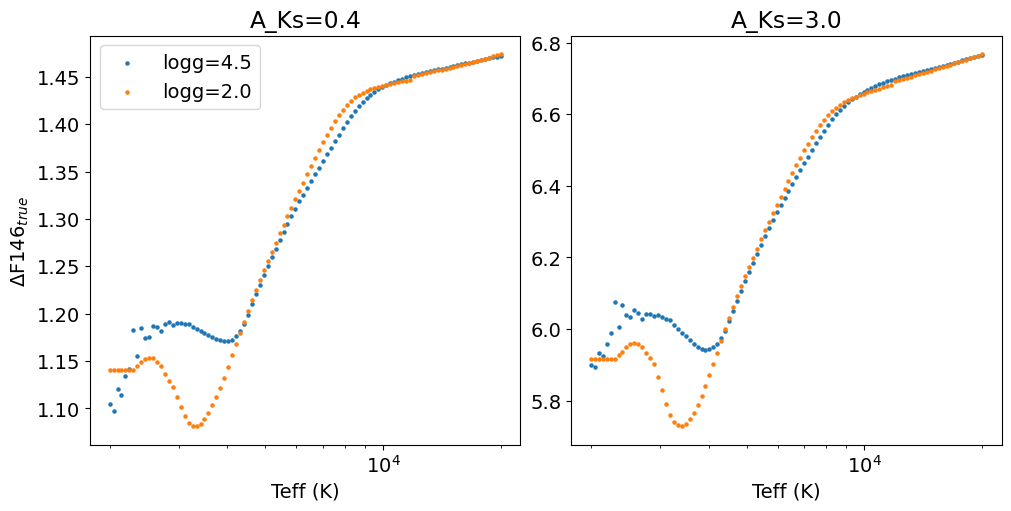

In [210]:
plt.rcParams['font.size'] = 14
fig,ax = plt.subplots(nrows=1, ncols=2,sharey=False, figsize=(10,5), layout='constrained')

idxs = (AKs_C_arr[:,0]==0.4) & (tab['logg']==4.5)
ax[0].scatter(tab['Teff'][idxs], F146_ext_arr[idxs], s=5, label='logg=4.5')
idxs = (AKs_C_arr[:,0]==0.4) & (tab['logg']==2.0)
ax[0].scatter(tab['Teff'][idxs], F146_ext_arr[idxs], s=5, label='logg=2.0')
           
idxs = (np.abs(AKs_C_arr[:,0]-3.0)<0.001) & (tab['logg']==4.5)
ax[1].scatter(tab['Teff'][idxs], F146_ext_arr[idxs], s=5, label='logg=4.5')
idxs = (np.abs(AKs_C_arr[:,0]-3.0)<0.001) & (tab['logg']==2.0)
ax[1].scatter(tab['Teff'][idxs], F146_ext_arr[idxs], s=5, label='logg=2.0')

#fig.colorbar(im1, ax=ax[1], label='AKs')
ax[0].set_title('A_Ks=0.4')
ax[1].set_title('A_Ks=3.0')
ax[0].set_xticks([3e3,1e4,2e4])
ax[0].legend()
ax[0].set_xlabel('Teff (K)'); ax[1].set_xlabel('Teff (K)')
ax[0].set_ylabel(r'$\Delta$F146$_{true}$')
ax[0].set_xscale('log'); ax[1].set_xscale('log')
fig.savefig('figures/ext_integ.png')

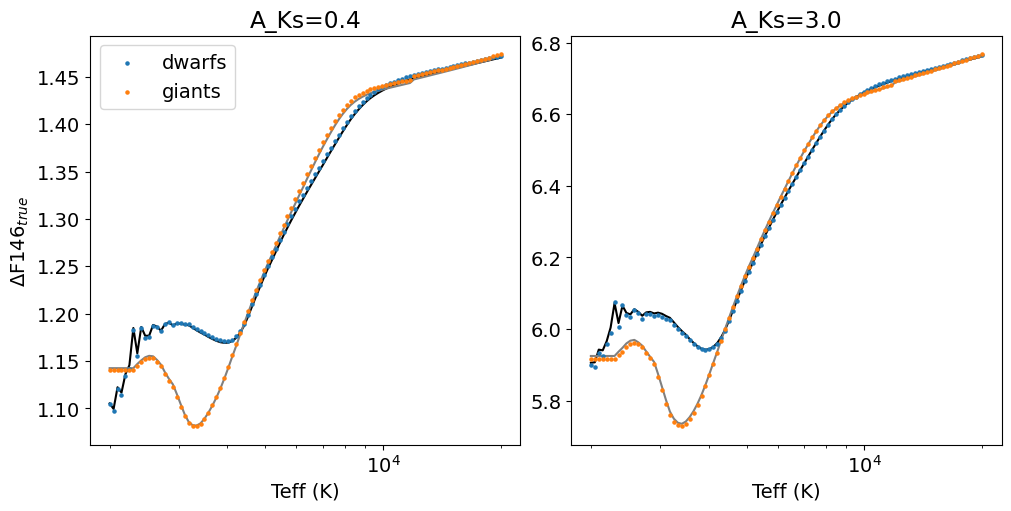

In [208]:
plt.rcParams['font.size'] = 14
fig,ax = plt.subplots(nrows=1, ncols=2,sharey=False, figsize=(10,5), layout='constrained')

idxs = (AKs_C_arr[:,0]==0.4) & (tab['logg']==4.5)
ax[0].plot(tab['Teff'][idxs], ext_ests[idxs], c='k', zorder=-1)
ax[0].scatter(tab['Teff'][idxs], F146_ext_arr[idxs], s=5, label='dwarfs')
idxs = (AKs_C_arr[:,0]==0.4) & (tab['logg']==2.0)
ax[0].plot(tab['Teff'][idxs], ext_ests[idxs], c='gray',zorder=-1)
ax[0].scatter(tab['Teff'][idxs], F146_ext_arr[idxs], s=5, label='giants')
           
idxs = (np.abs(AKs_C_arr[:,0]-3.0)<0.001) & (tab['logg']==4.5)
ax[1].plot(tab['Teff'][idxs], ext_ests[idxs], c='k', zorder=-1)
ax[1].scatter(tab['Teff'][idxs], F146_ext_arr[idxs], s=5, label='dwarfs')
idxs = (np.abs(AKs_C_arr[:,0]-3.0)<0.001) & (tab['logg']==2.0)
ax[1].plot(tab['Teff'][idxs], ext_ests[idxs], c='gray',zorder=-1)
ax[1].scatter(tab['Teff'][idxs], F146_ext_arr[idxs], s=5, label='dwarfs')

#fig.colorbar(im1, ax=ax[1], label='AKs')
ax[0].set_title('A_Ks=0.4')
ax[1].set_title('A_Ks=3.0')
ax[0].set_xticks([3e3,1e4,2e4])
ax[0].legend()
ax[0].set_xlabel('Teff (K)'); ax[1].set_xlabel('Teff (K)')
ax[0].set_ylabel(r'$\Delta$F146$_{true}$')
ax[0].set_xscale('log'); ax[1].set_xscale('log')
fig.savefig('figures/ext_integ_with_fit.png')

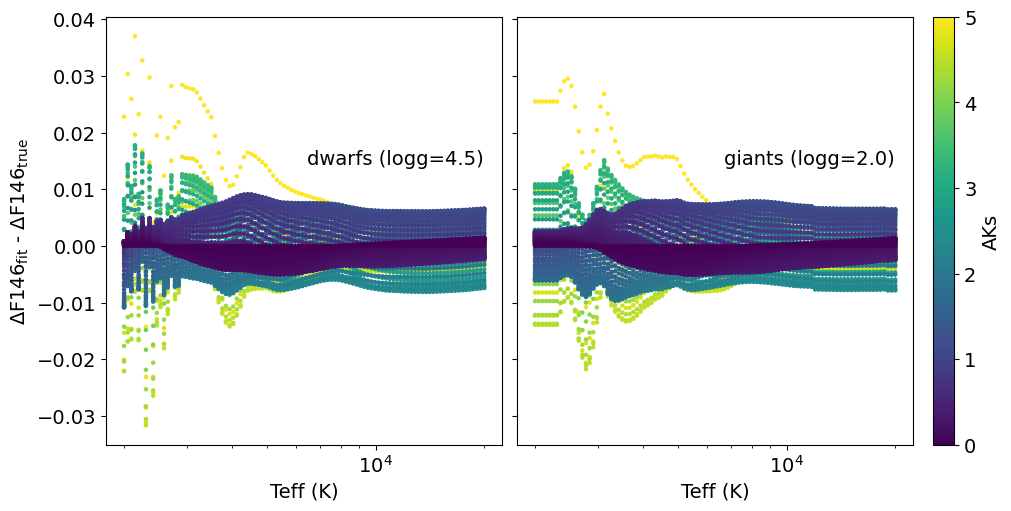

In [116]:
plt.rcParams['font.size'] = 14
fig,ax = plt.subplots(nrows=1, ncols=2,sharey=True, figsize=(10,5), layout='constrained')

idxs = tab['logg']==4.5
ax[0].scatter(tab['Teff'][idxs], ext_ests[idxs]-F146_ext_arr[idxs], 
            c=AKs_C_arr[idxs,0],s=5)
idxs = tab['logg']==2.0
im1 = ax[1].scatter(tab['Teff'][idxs], ext_ests[idxs]-F146_ext_arr[idxs], 
              c=AKs_C_arr[idxs,0],s=5)

fig.colorbar(im1, ax=ax[1], label='AKs')
ax[0].text(2e4, 0.017,'dwarfs (logg=4.5)', va='top',ha='right')
ax[1].text(2e4, 0.017,'giants (logg=2.0)', va='top',ha='right')
ax[0].set_xlabel('Teff (K)'); ax[1].set_xlabel('Teff (K)')
ax[0].set_ylabel(r'$\Delta$F146$_{\rm fit}$ - $\Delta$F146$_{\rm true}$')
ax[0].set_xscale('log'); ax[1].set_xscale('log')
fig.savefig('figures/ext_corr_grid.png')

In [117]:
tabs = []
for aks in np.flip(np.arange(0.0,5.001, 0.5)):
    print(aks)
    tab0 = get_grid_phot(aks,metallicity=0.5,logg=4.5)
    tab1 = get_grid_phot(aks,metallicity=0.5,logg=2)
    tabs.append(tab0)
    tabs.append(tab1)
tab_p0_5 = pd.concat(tabs)

5.0
4.5
4.0
3.5
3.0
Found saved file isos/grid_AKs_3.00_met_0.50_logg_4.5.csv
Found saved file isos/grid_AKs_3.00_met_0.50_logg_2.0.csv
2.5
Found saved file isos/grid_AKs_2.50_met_0.50_logg_4.5.csv
Found saved file isos/grid_AKs_2.50_met_0.50_logg_2.0.csv
2.0
Found saved file isos/grid_AKs_2.00_met_0.50_logg_4.5.csv
Found saved file isos/grid_AKs_2.00_met_0.50_logg_2.0.csv
1.5
Found saved file isos/grid_AKs_1.50_met_0.50_logg_4.5.csv
Found saved file isos/grid_AKs_1.50_met_0.50_logg_2.0.csv
1.0
Found saved file isos/grid_AKs_1.00_met_0.50_logg_4.5.csv
Found saved file isos/grid_AKs_1.00_met_0.50_logg_2.0.csv
0.5
Found saved file isos/grid_AKs_0.50_met_0.50_logg_4.5.csv
Found saved file isos/grid_AKs_0.50_met_0.50_logg_2.0.csv
0.0
Found saved file isos/grid_AKs_0.00_met_0.50_logg_4.5.csv
Found saved file isos/grid_AKs_0.00_met_0.50_logg_2.0.csv


In [118]:
alt_F146_ext_arr = tab_p0_5['delta_f146'].to_numpy()
alt_ext_ests = func_3color(tab_p0_5[['A_Ks', 'f106_f129_abs', 'f129_f158_abs', 'f158_f184_abs', 'Teff']].to_numpy(),
                           *res[0])
alt_AKs = tab_p0_5['A_Ks'].to_numpy()

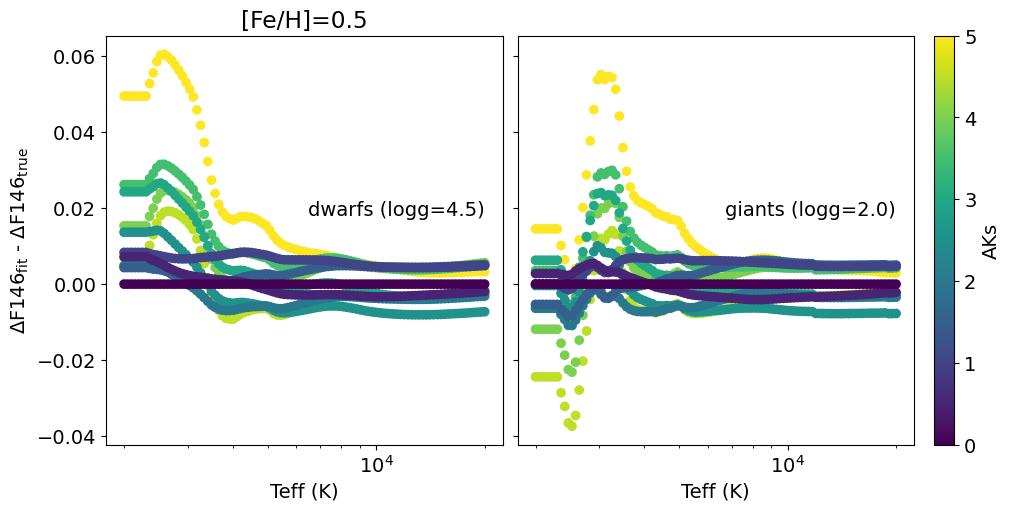

In [119]:
plt.rcParams['font.size'] = 14
fig,ax = plt.subplots(nrows=1, ncols=2,sharey=True, figsize=(10,5), layout='constrained')

idxs = tab_p0_5['logg']==4.5
ax[0].scatter(tab_p0_5['Teff'][idxs], alt_ext_ests[idxs]-alt_F146_ext_arr[idxs], 
              c=alt_AKs[idxs])
idxs = tab_p0_5['logg']==2.0
im1 = ax[1].scatter(tab_p0_5['Teff'][idxs], alt_ext_ests[idxs]-alt_F146_ext_arr[idxs], 
              c=alt_AKs[idxs])

fig.colorbar(im1, ax=ax[1], label='AKs')
ax[0].set_title('[Fe/H]=0.5')
ax[0].text(2e4, 0.022,'dwarfs (logg=4.5)', va='top',ha='right')
ax[1].text(2e4, 0.022,'giants (logg=2.0)', va='top',ha='right')
ax[0].set_xlabel('Teff (K)'); ax[1].set_xlabel('Teff (K)')
ax[0].set_ylabel(r'$\Delta$F146$_{\rm fit}$ - $\Delta$F146$_{\rm true}$')
ax[0].set_xscale('log'); ax[1].set_xscale('log')
fig.savefig('figures/ext_corr_grid_p0_5.png')

In [120]:
tabs = []
for aks in np.flip(np.arange(0.0,5.001, 0.5)):
    print(aks)
    tab0 = get_grid_phot(aks,metallicity=-1.0,logg=4.5)
    tab1 = get_grid_phot(aks,metallicity=-1.0,logg=2)
    tabs.append(tab0)
    tabs.append(tab1)
tab_m1 = pd.concat(tabs)

5.0
4.5
4.0
3.5
3.0
Found saved file isos/grid_AKs_3.00_met_-1.00_logg_4.5.csv
Found saved file isos/grid_AKs_3.00_met_-1.00_logg_2.0.csv
2.5
Found saved file isos/grid_AKs_2.50_met_-1.00_logg_4.5.csv
Found saved file isos/grid_AKs_2.50_met_-1.00_logg_2.0.csv
2.0
Found saved file isos/grid_AKs_2.00_met_-1.00_logg_4.5.csv
Found saved file isos/grid_AKs_2.00_met_-1.00_logg_2.0.csv
1.5
Found saved file isos/grid_AKs_1.50_met_-1.00_logg_4.5.csv
Found saved file isos/grid_AKs_1.50_met_-1.00_logg_2.0.csv
1.0
Found saved file isos/grid_AKs_1.00_met_-1.00_logg_4.5.csv
Found saved file isos/grid_AKs_1.00_met_-1.00_logg_2.0.csv
0.5
Found saved file isos/grid_AKs_0.50_met_-1.00_logg_4.5.csv
Found saved file isos/grid_AKs_0.50_met_-1.00_logg_2.0.csv
0.0
Found saved file isos/grid_AKs_0.00_met_-1.00_logg_4.5.csv
Found saved file isos/grid_AKs_0.00_met_-1.00_logg_2.0.csv


In [121]:
alt_F146_ext_arr = tab_m1['delta_f146'].to_numpy()
alt_ext_ests = func_3color(tab_m1[['A_Ks', 'f106_f129_abs', 'f129_f158_abs', 'f158_f184_abs', 'Teff']].to_numpy(),
                           *res[0])
alt_AKs = tab_m1['A_Ks'].to_numpy()

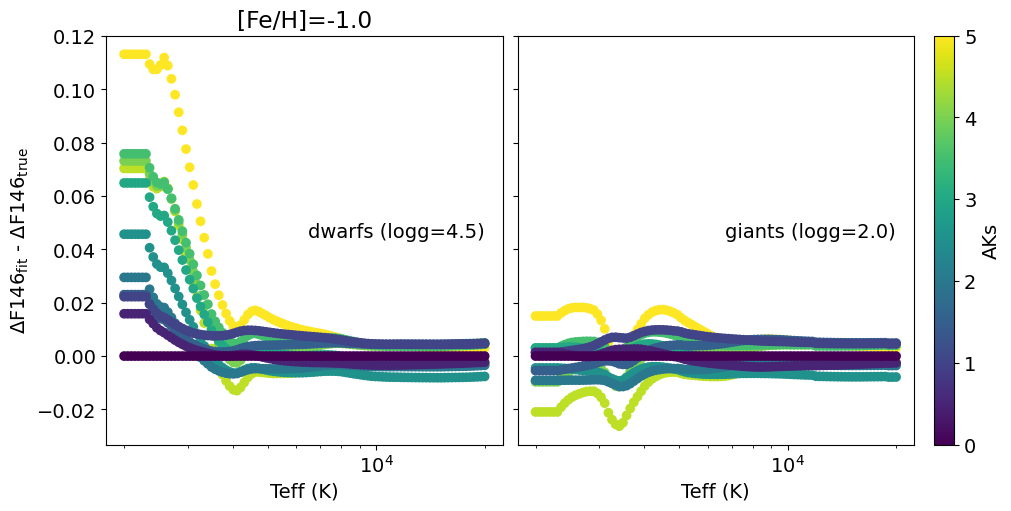

In [122]:
plt.rcParams['font.size'] = 14
fig,ax = plt.subplots(nrows=1, ncols=2,sharey=True, figsize=(10,5), layout='constrained')

idxs = tab_m1['logg']==4.5
ax[0].scatter(tab_m1['Teff'][idxs], alt_ext_ests[idxs]-alt_F146_ext_arr[idxs], 
              c=alt_AKs[idxs])
idxs = tab_m1['logg']==2.0
im1 = ax[1].scatter(tab_m1['Teff'][idxs], alt_ext_ests[idxs]-alt_F146_ext_arr[idxs], 
              c=alt_AKs[idxs])

fig.colorbar(im1, ax=ax[1], label='AKs')
ax[0].set_title('[Fe/H]=-1.0')
ax[0].text(2e4, 0.05,'dwarfs (logg=4.5)', va='top',ha='right')
ax[1].text(2e4, 0.05,'giants (logg=2.0)', va='top',ha='right')
ax[0].set_xlabel('Teff (K)'); ax[1].set_xlabel('Teff (K)')
ax[0].set_ylabel(r'$\Delta$F146$_{\rm fit}$ - $\Delta$F146$_{\rm true}$')
ax[0].set_xscale('log'); ax[1].set_xscale('log')
fig.savefig('figures/ext_corr_grid_m1.png')

In [85]:
# Get test synthpop catalogs for lower bulge and GC, then instead of a grid, use these stars'
# Teff, logg, metallicity, AKs to generate the star set, and evaluate the fit performance on each.

In [86]:
#import synthpop as sp
import tqdm

In [35]:
# mod = sp.SynthPop('huston2025_defaults.synthpop_conf', 
#             maglim=["W146", 99,"remove"],
#             post_processing_kwargs=[{"name": "ProcessDarkCompactObjects","remove": True},
#                                     {"name": "ConvertMistMags","conversions": {"AB": 
#                                         ["R062","Z087","Y106","J129","W146","H158","F184"]}}],
#             obsmag=False
#            )

# mod.init_populations()

# cat_lb,_ = mod.process_location(0.5,-1.4,1e-3)
# cat_gc,_ = mod.process_location(0,0,3e-4)

In [87]:
cat_lb = pd.read_csv('outputfiles/default/Huston2025_l0.500_b-1.400.csv')
cat_gc = pd.read_csv('outputfiles/default/Huston2025_l0.000_b0.000.csv')

In [88]:
cat_lb.columns

Index(['pop', 'iMass', 'age', 'Fe/H_initial', 'Mass', 'In_Final_Phase', 'Dist',
       'l', 'b', 'vr_bc', 'mul', 'mub', 'x', 'y', 'z', 'U', 'V', 'W', 'VR_LSR',
       'A_Ks', 'log_L', 'log_Teff', 'log_g', '[Fe/H]', 'log_R', 'phase',
       'R062', 'Z087', 'Y106', 'J129', 'W146', 'H158', 'F184', 'Bessell_U',
       'Bessell_B', 'Bessell_V', 'Bessell_R', 'Bessell_I', '2MASS_J',
       '2MASS_H', '2MASS_Ks'],
      dtype='object')

In [89]:
cat_lb

,pop,iMass,age,Fe/H_initial,Mass,In_Final_Phase,Dist,l,b,vr_bc,...,H158,F184,Bessell_U,Bessell_B,Bessell_V,Bessell_R,Bessell_I,2MASS_J,2MASS_H,2MASS_Ks
0,0.0,0.121104,10.000000,0.233574,0.121103,0.0,3.180436,0.504077,-1.390123,53.330493,...,10.922027,11.157322,19.362155,18.306770,16.682024,14.692563,12.581657,10.091001,9.431845,9.175717
1,0.0,0.309939,10.000000,0.269445,0.309923,0.0,3.883992,0.494355,-1.404888,-29.447889,...,8.711004,8.859564,14.632026,13.821148,12.500989,11.204671,9.566736,7.906523,7.288079,7.066653
2,0.0,0.625685,10.000000,-0.243294,0.625638,0.0,4.192784,0.511834,-1.392219,-56.470734,...,6.167224,6.270660,9.414685,8.528850,7.446023,6.784218,6.239535,5.442373,4.780589,4.685909
3,0.0,0.202399,10.000000,-0.378759,0.202396,0.0,4.337780,0.498812,-1.412702,-13.256637,...,9.195394,9.296621,14.294525,13.067173,11.591071,10.602296,9.588953,8.456747,7.794420,7.585031
4,0.0,0.112743,10.000000,-0.469895,0.112742,0.0,4.314851,0.503810,-1.401414,-77.344076,...,10.567872,10.701905,17.038580,15.447716,13.776670,12.587317,11.226379,9.868818,9.144912,8.921878
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
614285,10.0,0.515449,8.542997,-0.162853,0.515432,0.0,24.829361,0.491548,-1.398864,-22.394654,...,7.054481,7.125625,11.442537,10.304606,8.974803,8.113185,7.324616,6.347920,5.655431,5.487231
614286,10.0,0.307319,7.868817,-0.114100,0.307315,0.0,24.864696,0.515035,-1.404743,-17.944733,...,8.460184,8.565295,13.575957,12.461353,11.052984,10.044546,8.911835,7.714086,7.057131,6.850557
614287,10.0,0.180470,9.335914,-0.160658,0.180468,0.0,24.995861,0.506695,-1.415963,-45.851603,...,9.564256,9.692260,15.226093,14.030451,12.545240,11.437297,10.137891,8.814367,8.152383,7.936538
614288,10.0,0.256161,8.006993,-0.545721,0.256158,0.0,24.921362,0.505684,-1.409378,-23.778042,...,8.702342,8.788399,13.448813,12.257370,10.811406,9.874933,9.006062,7.961291,7.306913,7.100511


In [99]:
def get_cat_grid_phot(cat0):
    cat = cat0.copy()
    filters_long=['roman,wfi,f062','roman,wfi,f087','roman,wfi,f106','roman,wfi,f129',
             'roman,wfi,f158','roman,wfi,f184','roman,wfi,f213','roman,wfi,f146']
    # filters_long=['wfirst,wfi,f106','wfirst,wfi,f129',
    #          'wfirst,wfi,f158','wfirst,wfi,f184','wfirst,wfi,f146']
    # fnames = [os.path.join(os.environ['PYSYN_CDBS'], 'comp', 'nonhst', 
    #                        '_'.join(filt.split(','))+'_001_syn.fits')
    #                        for filt in filters_long]
    filter_objs = [synthetic.get_filter_info(f) for f in filters_long]
    filters_short = [f.split(',')[-1] for f in filters_long]
    ab_vega1 =  (synthetic.calc_ab_vega_filter_conversion(filters_long[2]) - 
                 synthetic.calc_ab_vega_filter_conversion(filters_long[3]))
    ab_vega2 =  (synthetic.calc_ab_vega_filter_conversion(filters_long[3]) - 
                 synthetic.calc_ab_vega_filter_conversion(filters_long[4]))
    ab_vega3 =  (synthetic.calc_ab_vega_filter_conversion(filters_long[4]) - 
                 synthetic.calc_ab_vega_filter_conversion(filters_long[5]))
    
    cat.loc[:,'f106_f129_abs'] = cat['Y106']-cat['J129']
    cat.loc[:,'f129_f158_abs'] = cat['J129']-cat['H158']
    cat.loc[:,'f158_f184_abs'] = cat['H158']-cat['F184']
    
    cat.loc[:,'Teff'] = 10**cat['log_Teff']
    cat.loc[:,'delta_f146_spec'] = np.nan
    for i in tqdm.tqdm(cat.index):
        spec_base = atm_func(metallicity=cat['Fe/H_initial'][i],
                             temperature=cat['Teff'][i], 
                             gravity=cat['log_g'][i])
        spec = copy.deepcopy(spec_base)  # in erg s^-1 cm^-2 A^-1
        red = red_law.reddening(cat['A_Ks'][i]).resample(spec.wave)
        spec *= red
        mag = synthetic.mag_in_filter(spec, filter_objs[-1])
        mag_base = synthetic.mag_in_filter(spec_base, filter_objs[-1])
        cat.loc[i,'delta_f146_spec'] = (mag-mag_base)
        mag106, mag129, mag158, mag184 = [synthetic.mag_in_filter(spec_base, filter_objs[j])
                                          for j in range(4)]
        cat.loc[i,'f106_f129_spi'] = mag106 - mag129 + ab_vega1
        cat.loc[i,'f129_f158_spi'] = mag129 - mag158 + ab_vega2
        cat.loc[i,'f158_f184_spi'] = mag158 - mag184 + ab_vega3
    
    # cat.loc[:,'delta_f146_fit'] = func_3color(cat[['A_Ks', 'f106_f129_abs', 'f129_f158_abs', 
    #                                                'f158_f184_abs', 'Teff']].to_numpy(), *res[0])
    # cat.loc[:,'delta_f146_fit_spi'] = func_3color(cat[['A_Ks', 'f106_f129_spi', 'f129_f158_spi', 
    #                                                'f158_f184_spi', 'Teff']].to_numpy(), *res[0])
    return cat

In [151]:
cat_ext = get_cat_grid_phot(cat_lb[::10])

For roman,wfi,f106, m_ab - m_vega = 0.6659690376827427
For roman,wfi,f129, m_ab - m_vega = 0.9739263057526699
For roman,wfi,f129, m_ab - m_vega = 0.9739263057526699
For roman,wfi,f158, m_ab - m_vega = 1.3088682252670338
For roman,wfi,f158, m_ab - m_vega = 1.3088682252670338
For roman,wfi,f184, m_ab - m_vega = 1.5764881750217157


  0%|                                       | 170/61429 [00:03<22:42, 44.97it/s]

Changing to met=0.50 for met=0.49 T=  2269 logg=5.08


  2%|▌                                      | 979/61429 [00:21<21:57, 45.88it/s]

Changing to met=0.50 for met=0.50 T=  2298 logg=5.07


...

 88%|████████████████████████████████▌    | 54058/61429 [19:32<02:39, 46.21it/s]

Changing to met=0.50 for met=0.48 T=  2265 logg=5.10


 88%|████████████████████████████████▋    | 54188/61429 [19:34<02:35, 46.56it/s]

Changing to met=-2.50 for met=-2.52 T=  5322 logg=4.74


100%|█████████████████████████████████████| 61429/61429 [22:11<00:00, 46.14it/s]


In [152]:
cat_ext.loc[:,'delta_f146_fit'] = func_3color(cat_ext[['A_Ks', 'f106_f129_abs', 'f129_f158_abs', 
                                                   'f158_f184_abs', 'Teff']].to_numpy(), *res[0])

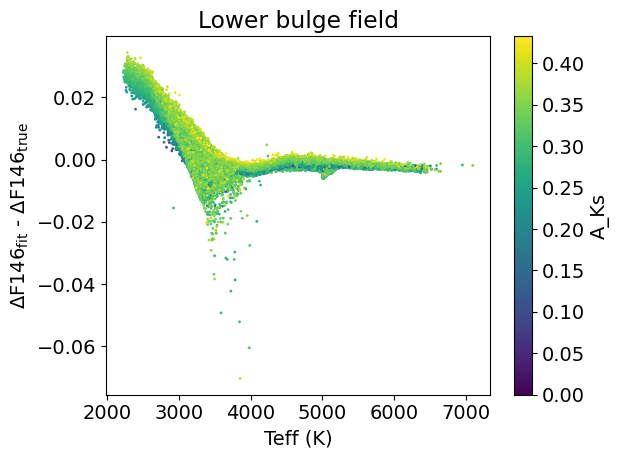

In [153]:
plt.scatter(cat_ext['Teff'],cat_ext['delta_f146_fit']-cat_ext['delta_f146_spec'], c=cat_ext['A_Ks'],
           vmin=0,s=1)
plt.colorbar(label='A_Ks')
plt.ylabel(r'$\Delta$F146$_{\rm fit}$ - $\Delta$F146$_{\rm true}$')
plt.xlabel('Teff (K)')
plt.title('Lower bulge field')
plt.tight_layout()
plt.savefig('figures/f146ext_lowerbulge_test.png')

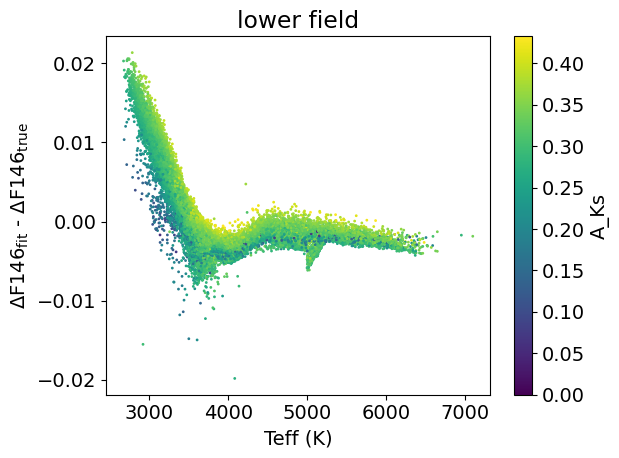

In [163]:
cat_ext_f146 = cat_ext['W146'] + 5*np.log10(100*cat_ext['Dist']) + cat_ext['delta_f146_fit']
keep = cat_ext_f146<=25
plt.scatter(cat_ext['Teff'][keep], cat_ext['delta_f146_fit'][keep]-cat_ext['delta_f146_spec'][keep], 
            c=cat_ext['A_Ks'][keep], vmin=0,s=1)
plt.colorbar(label='A_Ks')
plt.ylabel(r'$\Delta$F146$_{\rm fit}$ - $\Delta$F146$_{\rm true}$')
plt.xlabel('Teff (K)')
plt.title('lower field')
plt.tight_layout()
plt.savefig('figures/f146ext_lb_test_cut.png')

In [150]:
cat_ext2 = get_cat_grid_phot(cat_gc[::10])

For roman,wfi,f106, m_ab - m_vega = 0.6659690376827427
For roman,wfi,f129, m_ab - m_vega = 0.9739263057526699
For roman,wfi,f129, m_ab - m_vega = 0.9739263057526699
For roman,wfi,f158, m_ab - m_vega = 1.3088682252670338
For roman,wfi,f158, m_ab - m_vega = 1.3088682252670338
For roman,wfi,f184, m_ab - m_vega = 1.5764881750217157


  1%|▏                                     | 660/124597 [00:14<43:42, 47.25it/s]

Changing to met=0.50 for met=0.47 T=  2295 logg=5.09


  1%|▎                                     | 830/124597 [00:17<44:50, 46.00it/s]

Changing to met=0.50 for met=0.50 T=  2237 logg=5.09


...

100%|██████████████████████████████████▉| 124371/124597 [49:50<00:04, 45.85it/s]

Changing to met=0.50 for met=0.48 T=  2279 logg=5.10
Changing to met=0.50 for met=0.49 T=  2245 logg=5.09


100%|██████████████████████████████████▉| 124541/124597 [49:53<00:01, 46.79it/s]

Changing to met=0.50 for met=0.49 T=  2248 logg=5.09


100%|███████████████████████████████████| 124597/124597 [49:54<00:00, 41.60it/s]


In [155]:
cat_ext2.loc[:,'delta_f146_fit'] = func_3color(cat_ext2[['A_Ks', 'f106_f129_abs', 'f129_f158_abs', 
                                                   'f158_f184_abs', 'Teff']].to_numpy(), *res[0])

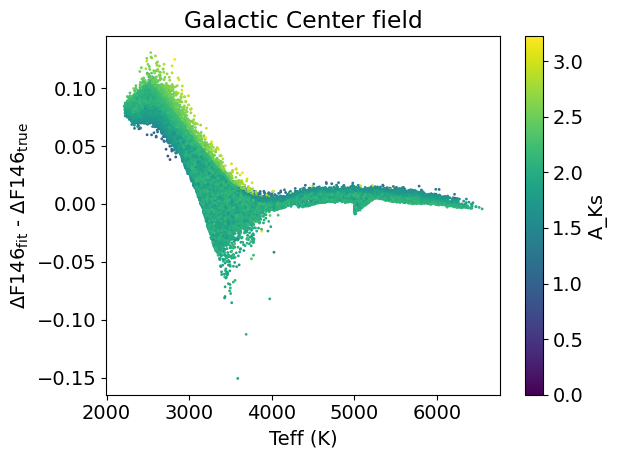

In [156]:
plt.scatter(cat_ext2['Teff'],cat_ext2['delta_f146_fit']-cat_ext2['delta_f146_spec'], c=cat_ext2['A_Ks'],
           vmin=0,s=1)
plt.colorbar(label='A_Ks')
plt.ylabel(r'$\Delta$F146$_{\rm fit}$ - $\Delta$F146$_{\rm true}$')
plt.xlabel('Teff (K)')
plt.title('Galactic Center field')
plt.tight_layout()
plt.savefig('figures/f146ext_gc_test.png')

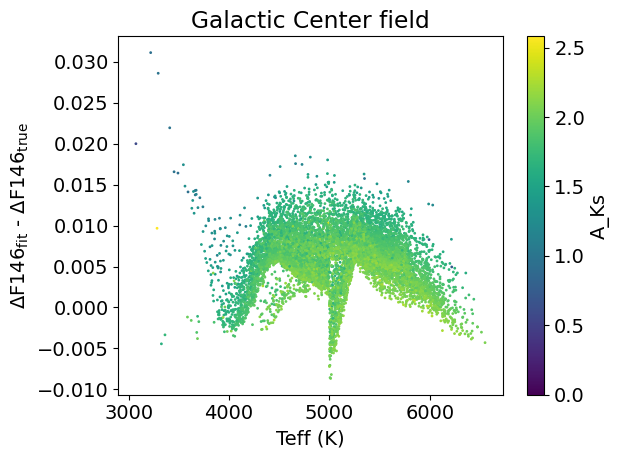

In [157]:
cat_ext2_f146 = cat_ext2['W146'] + 5*np.log10(100*cat_ext2['Dist']) + cat_ext2['delta_f146_fit']
keep = cat_ext2_f146<=25
plt.scatter(cat_ext2['Teff'][keep], cat_ext2['delta_f146_fit'][keep]-cat_ext2['delta_f146_spec'][keep], 
            c=cat_ext2['A_Ks'][keep], vmin=0,s=1)
plt.colorbar(label='A_Ks')
plt.ylabel(r'$\Delta$F146$_{\rm fit}$ - $\Delta$F146$_{\rm true}$')
plt.xlabel('Teff (K)')
plt.title('Galactic Center field')
plt.tight_layout()
plt.savefig('figures/f146ext_gc_test_cut.png')

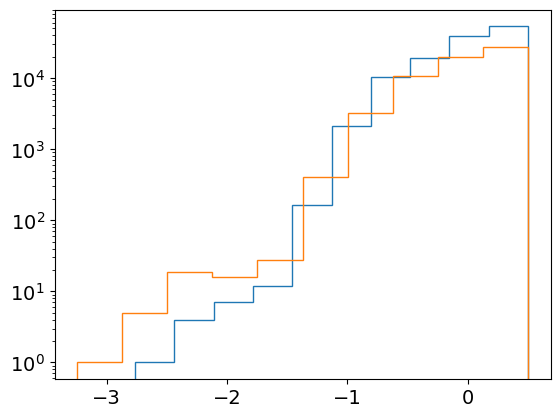

In [164]:
plt.hist(cat_ext2['Fe/H_initial'], histtype='step')
plt.hist(cat_ext['Fe/H_initial'], histtype='step')
plt.yscale('log')

In [167]:
cat_ext.to_hdf('outputfiles/lb_simtab.h5',key='data', index=False)
cat_ext2.to_hdf('outputfiles/gc_simtab.h5',key='data', index=False)